<a href="https://colab.research.google.com/github/Dev-Maidul/ML-Assignments/blob/main/ML_Mid_Term.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
sns.set_theme( style='darkgrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)

#Question 1: Exploratory Data Analysis (EDA) -20

In [44]:
df = pd.read_csv("/content/adult_income.csv")

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [45]:
print(df.shape)
df.info()
df.describe()

(48842, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [46]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [47]:
df['income'] = df['income'].str.replace('.', '', regex=False)
df['income'].value_counts()

,count
income,
<=50K,37155
>50K,11687


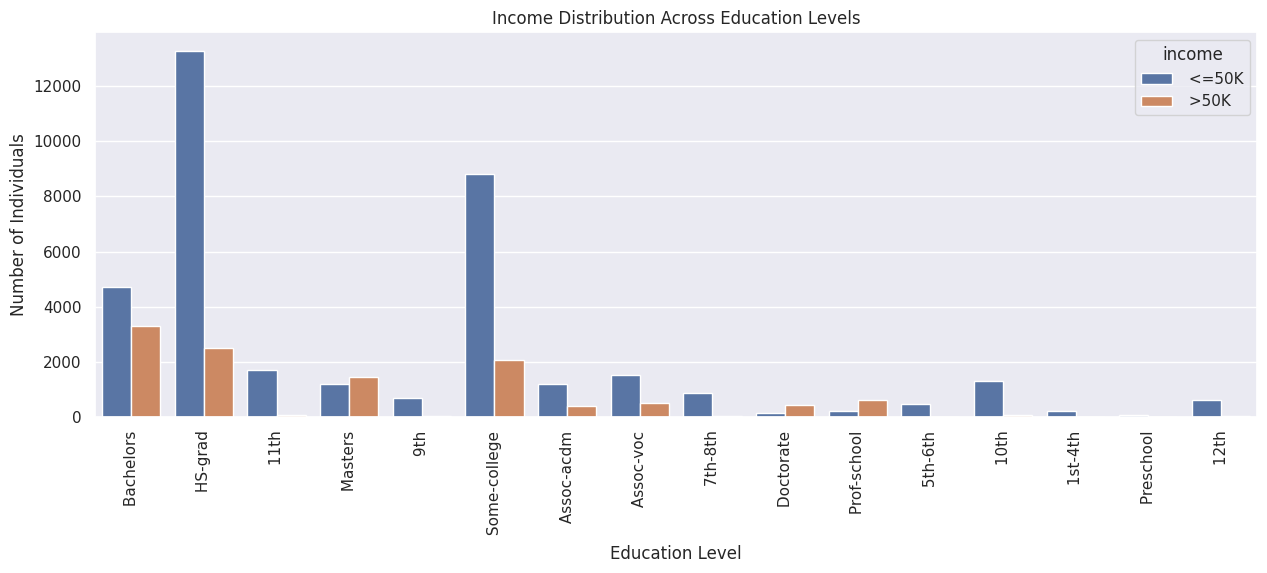

In [48]:
plt.figure(figsize=(15,5))
sns.countplot(
    data=df,
    x='education',
    hue='income'
)
plt.title("Income Distribution Across Education Levels")
plt.xlabel("Education Level")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=90)
plt.show()

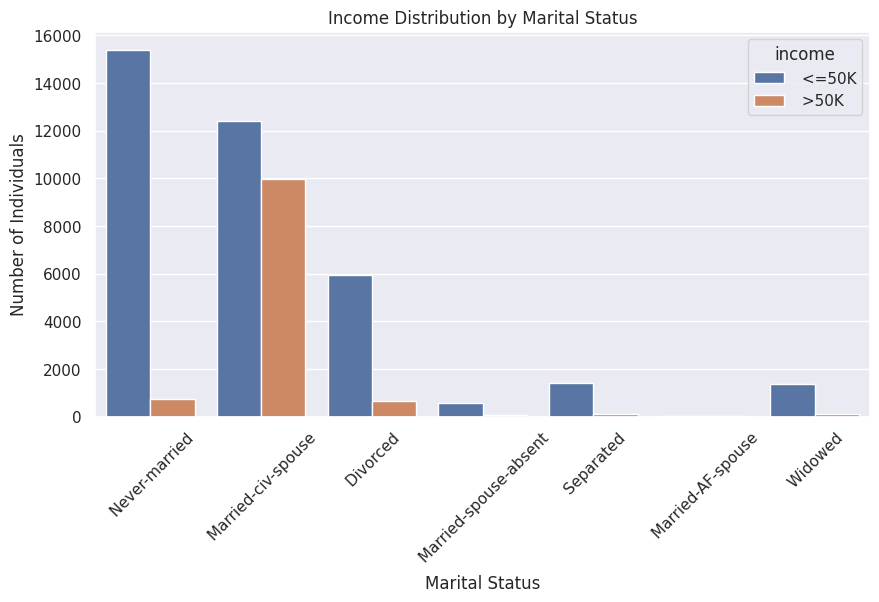

In [49]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='marital-status',
    hue='income'
)
plt.title("Income Distribution by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=45)
plt.show()

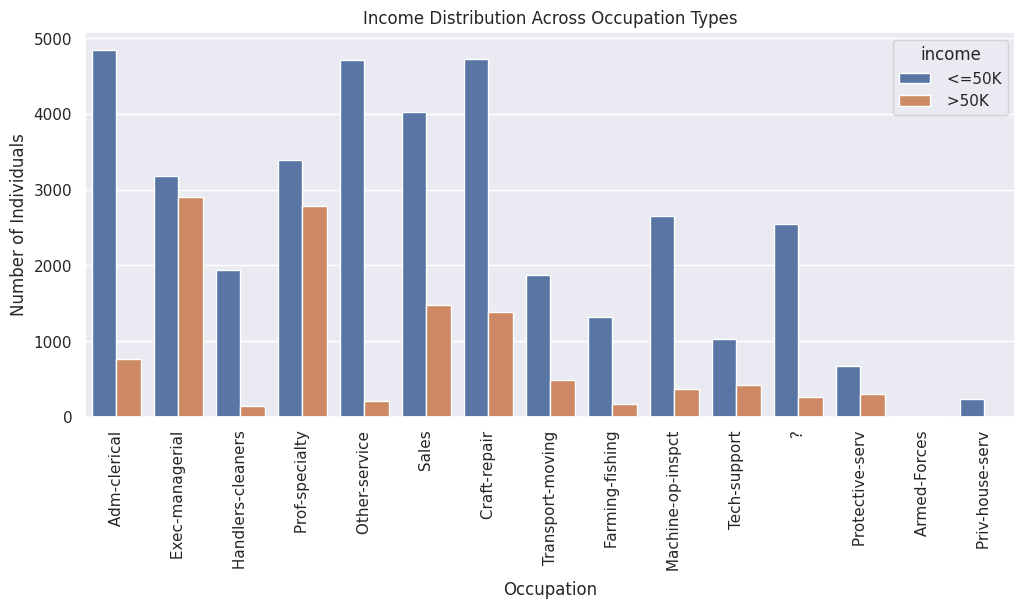

In [50]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='occupation',
    hue='income'
)
plt.title("Income Distribution Across Occupation Types")
plt.xlabel("Occupation")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=90)
plt.show()

In [51]:
pd.crosstab(
    df['education'],
    df['income'],
    normalize='index'
)*100

income,<=50K,>50K
education,,
10th,93.736501,6.263499
11th,94.922737,5.077263
12th,92.694064,7.305936
1st-4th,96.761134,3.238866
5th-6th,94.695481,5.304519
7th-8th,93.507853,6.492147
9th,94.576720,5.423280
Assoc-acdm,74.203623,25.796377
Assoc-voc,74.672489,25.327511


In [52]:
pd.crosstab(
    df['marital-status'],
    df['income'],
    normalize='index'
)*100

income,<=50K,>50K
marital-status,,
Divorced,89.883914,10.116086
Married-AF-spouse,62.162162,37.837838
Married-civ-spouse,55.386747,44.613253
Married-spouse-absent,90.764331,9.235669
Never-married,95.452007,4.547993
Separated,93.529412,6.470588
Widowed,91.567852,8.432148


In [53]:
pd.crosstab(
    df['occupation'],
    df['income'],
    normalize='index'
)*100

income,<=50K,>50K
occupation,,
?,90.566038,9.433962
Adm-clerical,86.312600,13.687400
Armed-Forces,66.666667,33.333333
Craft-repair,77.372382,22.627618
Exec-managerial,52.218206,47.781794
Farming-fishing,88.389262,11.610738
Handlers-cleaners,93.339768,6.660232
Machine-op-inspct,87.690271,12.309729
Other-service,95.856185,4.143815


# Feature Ranking

1. Education
2. Occupation
3. Marital Status

## Top 3 Factors Influencing Income



1.   Education is ranked first because the difference between income groups is most clearly visible. Higher educational qualifications consistently correspond to higher earning potential.
2.   Occupation directly determines salary ranges and career opportunities.

3. Marital status shows a strong relationship with income but may indirectly reflect age, experience, and stability.


# Question 2: Preprocessing Pipeline Design (Regression) - 20

In [54]:
X = df.drop('hours-per-week', axis=1)
y = df['hours-per-week']

In [55]:
num_cols = X.select_dtypes(include=['int64','float64']).columns

cat_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'], dtype='object')

Categorical Columns:
Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')


In [56]:


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [57]:
num_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [58]:


cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [59]:
cat_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [60]:


preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [61]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object'))])

In [62]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor)
])
full_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object'))]))])

In [63]:
X_processed = full_pipeline.fit_transform(X)

print("Preprocessing Completed")
print(X_processed.shape)

Preprocessing Completed
(48842, 109)


###The numerical features were processed using a pipeline consisting of SimpleImputer(strategy='median') and StandardScaler(). Median imputation was chosen because it is less sensitive to outliers. StandardScaler was applied to normalize feature scales and improve model performance.

###The categorical features were processed using a pipeline consisting of SimpleImputer(strategy='most_frequent') and OneHotEncoder(handle_unknown='ignore'). Missing values were replaced with the most common category, and OneHotEncoder was used to convert categorical variables into machine-readable numerical format.

###A ColumnTransformer was used to apply different preprocessing steps to numerical and categorical columns simultaneously. This ensures that each feature type receives the most appropriate transformation.

#Question 3: Regression Modeling & Evaluation - 20

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [65]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [66]:
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [67]:
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_lr

array([39.76482872, 30.56398516, 38.58043475, ..., 46.93137835,
       45.89941233, 45.21210726])

In [68]:
lr_r2 = r2_score(y_test, y_pred_lr)

lr_mae = mean_absolute_error(y_test, y_pred_lr)

lr_mse = mean_squared_error(y_test, y_pred_lr)

print("Linear Regression Results")
print("R2:", lr_r2)
print("MAE:", lr_mae)
print("MSE:", lr_mse)

Linear Regression Results
R2: 0.20153918063841003
MAE: 7.657295242692231
MSE: 122.41841260809666


In [69]:
sgd_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SGDRegressor(
        random_state=42,
        max_iter=1000,
        tol=1e-3
    ))
])

In [70]:
sgd_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object'))])),
                ('model', SGDRegressor(random_state=42))])

In [71]:
y_pred_sgd = sgd_pipeline.predict(X_test)

In [72]:
sgd_r2 = r2_score(y_test, y_pred_sgd)

sgd_mae = mean_absolute_error(y_test, y_pred_sgd)

sgd_mse = mean_squared_error(y_test, y_pred_sgd)

print("SGD Regressor Results")
print("R2:", sgd_r2)
print("MAE:", sgd_mae)
print("MSE:", sgd_mse)

SGD Regressor Results
R2: 0.2023939185698942
MAE: 7.6399480032584695
MSE: 122.28736590144439


In [73]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'SGD Regressor'],
    'R2': [lr_r2, sgd_r2],
    'MAE': [lr_mae, sgd_mae],
    'MSE': [lr_mse, sgd_mse]
})

results

,Model,R2,MAE,MSE
0,Linear Regression,0.201539,7.657295,122.418413
1,SGD Regressor,0.202394,7.639948,122.287366


Both Linear Regression and SGD Regressor achieved very similar performance in predicting hours-per-week. However, the SGD Regressor performed slightly better overall. It obtained a higher R² score (0.202394 vs 0.201539), indicating that it explained a slightly greater proportion of the variance in the target variable. Additionally, the SGD Regressor achieved lower MAE (7.639948) and MSE (122.287366) values compared to Linear Regression, suggesting more accurate predictions with smaller errors.

Therefore, the SGD Regressor is considered the better-performing model for this dataset. However, the performance difference between the two models is very small, indicating that both models behave similarly on this prediction task.

# Question 4: Classification Pipeline & Error Analysis -20

In [74]:
X = df.drop('income', axis=1)
y = df['income']

In [75]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [76]:
num_cols = X.select_dtypes(
    include=['int64','float64']
).columns

cat_cols = X.select_dtypes(
    include=['object']
).columns

In [77]:


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [78]:


cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [79]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [82]:


log_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [84]:
log_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [85]:
y_pred = log_pipeline.predict(X_test)

In [89]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

In [91]:
precision = precision_score(
    y_test,
    y_pred,
    pos_label=' >50K'
)

In [92]:
recall = recall_score(
    y_test,
    y_pred,
    pos_label=' >50K'
)

In [93]:
print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))

Accuracy : 0.8508
Precision: 0.741
Recall   : 0.5856


The Logistic Regression model achieved an accuracy of 85.08%, precision of 74.10%, and recall of 58.56%. The model performed well overall and made reliable predictions for high-income individuals. However, the lower recall suggests that some people earning more than $50K were not correctly identified.